
## RISK MANAGEMENT
MODULE 7 | LESSON 4


---

# **CREDIT AND CLIMATE RISK IN PYTHON**




|  |  |
|:---|:---|
|**Reading Time** |  30 minutes |
|**Prior Knowledge** |Vasicek credit model, Three-factor credit model  |
|**Keywords** |Value at Risk, Expected Tail Loss, Expected Shortfall, Basic credit concepts, e.g., Recovery rate, Probability of default, Loss given default, Exposure at default  |


---

*In the last lesson, we discussed the Merton and Vasicek approaches to modeling probability of default in general terms, while in this lesson, we get very hands-on by modeling a rather simple ten-loan portfolio. The same logic and much of the same code can be used to model a much larger portfolio with only a few tweaks here and there.*



## **1. Expected Loss**

In [1]:
import time

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

Let's look at section "5.3 An explicit and simple case" starting on page 14 (Garnier et al.), make the assumptions they make there, and calculate the 99.9% (Value at Risk) VaR--here meaning that $\alpha = 0.001$. 

We will supply a few necessary inputs:


*   The probability of default (PD) vector, referred to by Garnier et al. as the probability of transitioning from any non-defaulted rating to the defaulted rating, ranges from 0.01% to 50%, denoted (.0001, .0005, .001, .005, .01, .05, .1, .25, .50)
*   The recovery rates (RR) for groups of assets in the same order as the PD in the vector are also assigned. 
*   We make a clean assumption that each of the ten assets is worth 1,000 units of currency, for notional portfolio value of one million units.
*   We also assume in this notebook that we are always using a one-year horizon over which to evaluate the various aspects of credit risk.


In [2]:
# Probabilities of Default
PD = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.25, 0.50, 0.65]
PD = np.asarray(PD)
PD

array([1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02, 5.0e-02, 1.0e-01,
       2.5e-01, 5.0e-01, 6.5e-01])

In [3]:
# Recovery Rates
RR = [1, 0.90, 0.80, 0.65, 0.50, 0.45, 0.35, 0.25, 0.10, 0]
RR = np.asarray(RR)
RR

array([1.  , 0.9 , 0.8 , 0.65, 0.5 , 0.45, 0.35, 0.25, 0.1 , 0.  ])

Remember that Loss Given Default (LGD) is just 1 - RR.

In [4]:
# Losses Given Default (1 - Recovery)
LGD = 1 - RR
LGD

array([0.  , 0.1 , 0.2 , 0.35, 0.5 , 0.55, 0.65, 0.75, 0.9 , 1.  ])

We provide Exposure At Default inputs, in this case assuming 1,000 currency units for each exposure.

In [5]:
# Exposure at time of Default
EAD = [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
EAD = np.asarray(EAD)
EAD

array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000])

The Expected Loss (EL) for the portfolio of loans is simply the sum of the PD times the EAD times the LGD for each loan.

In [6]:
EL = (PD * EAD * LGD).sum()
EL

1387.0

We have just calculated our Expected Loss which "is simply the sum of the expected individual losses" (Garnier et al. 2), which is a scalar as expected. Compare what we have just done to Section 3: Expected Loss" in the reading by Garnier et al., especially equations 3-5 (Garnier et al. 6). Note this calculation was deterministic; we did not require any stochastic variables.


## **2. Value at Risk and Expected Shortfall**

### **2.1 Brute Force Approach to Monte Carlo Simulation (MCS)**

What if we wanted to understand that distribution of portfolio losses beyond the mere expectation? For this, we use Monte Carlo simulation (MCS). In each simulation, we assume that a loan defaults if the value of the uniform random variable (in the range [0,1]) to which it is assigned is less than the PD; conversely, it does not default if the uniform random variable's value is greater than the PD. Make sure that this approach makes sense to you. 

In [7]:
# Simulate!
simulation_number = 5 * 10**5
simulated_losses = []

for sim in tqdm(range(simulation_number)):
    # Find out which loans defaulted in this simulation
    # Simulate 10 independent uniform random variables (on 0 to 1), i.e., one for each loan
    uniform_rvs = np.random.default_rng().uniform(low=0, high=1, size=10)

    # For each random uniform, if the simulated value is less than the PD
    # then consider that loan as defaulted in this simulation (1=defaulted)
    defaulted_loans = (uniform_rvs < PD).astype(
        int
    )  # Vector of 0s and 1s, representing non-defaults and defaults, respectively

    # Given the loans that defaulted in this simulation, calculate this simulation's loss
    sim_loss = (defaulted_loans * LGD * EAD).sum()

    # Save the simulated outcome
    simulated_losses.append(sim_loss)

100%|██████████| 500000/500000 [01:24<00:00, 5950.92it/s]


In [8]:
# Here is our distribution of losses
# We can check that the empirical mean matches the calculated expectation
sim_losses = pd.Series(simulated_losses)
sim_losses.describe(
    percentiles=[0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
)  # Summary statistics
# sim_losses.value_counts().sort_values() #See simulated loss amounts by frequency

count    500000.000000
mean       1387.123700
std         768.759994
min           0.000000
1%            0.000000
10%           0.000000
20%         900.000000
30%        1000.000000
40%        1000.000000
50%        1500.000000
60%        1750.000000
70%        1900.000000
80%        1900.000000
90%        2550.000000
99%        3200.000000
max        4350.000000
dtype: float64

Using just this output, we can already visualize the distribution of losses in our minds, but we have these amazing visualization tools in Python, so let's not have them go to waste. 

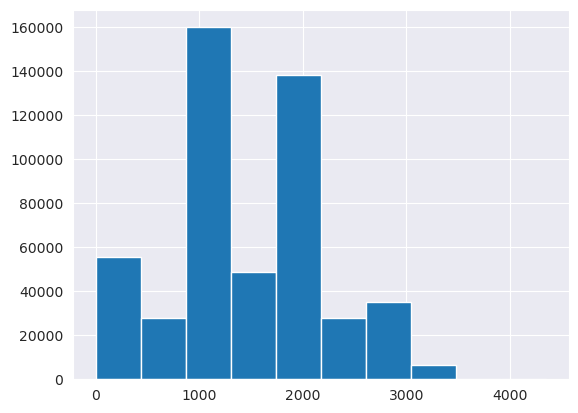

In [9]:
# Also note that in each simulation there is a finite number of possible outcomes
# so the distribution might not look so smooth
with sns.axes_style("darkgrid"):
    sim_losses.hist()

Note that in each simulation there is a finite number of possible outcomes so the distribution does not look smooth. Also, of course, it is not symmetric. 

Next, we want to find the 99.9th percentile (which we could have included in the `description` above) to get our estimate of the Value at Risk for this portfolio.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [10]:
# Say we want to know the max loss X percent of the time
# We want the quantile of the loss distribution
sim_losses.quantile(0.999)

3300.0

Now let us find the Expected Tail Loss or Expected Shortfall for the 99.9th percentile. This is the expectation for the losses that are greater than the Value at Risk (VaR) value that we just found. That is, the average of losses in the 0.1% percentile of losses that are greater than the VaR.

In [11]:
# In the worse .1% of the scenarios, what is our average loss?
alpha = 0.001
print(
    "Average loss in worst .1% of simulations",
    sim_losses.sort_values(ascending=False)
    .iloc[: int(simulation_number * alpha)]
    .mean(),
)
print(
    "Sample size for worst .1% of simulations", simulation_number * alpha
)  # sim_losses.sort_values(ascending=False).iloc[ :int(simulation_number * alpha) ].shape[0] )

Average loss in worst .1% of simulations 3621.5
Sample size for worst .1% of simulations 500.0



### **2.2 Fast and Elegant Approach to Monte Carlo Simulation (MCS)**

We do the same thing but without the for-loop to be more computationally efficient and make use of cleaner, more elegant code. That said, the approach is basically the same:

1. Simulate uniform random variables
2. Get vectors of defaulted loan binaries (1 for default, 0 for non-default)
3. Calculate losses for quantiles of interest.

In [12]:
start = time.time()
simulation_number = 5 * 10**5

# Matrix of independent random uniforms
# Each row (with 10 columns) corresponds to a single simulation
simulated_uniforms = pd.DataFrame(
    np.random.default_rng().uniform(low=0, high=1, size=(simulation_number, 10))
)

# For each row, get True/False for whether or not each loan defaulted
# Convert to binary for consistency with above (1=defaulted)
# Note the intermediate step of creating a matrix by repeatedly stacking our PD vector
PD_matrix = np.array([PD for _ in range(simulation_number)])
defaulted_loans = (simulated_uniforms < PD_matrix).astype(int)

# Calculate the loss by simulation
# Defaulted * LGD * EAD
simulations = defaulted_loans.to_numpy() @ (LGD * EAD)
end = time.time()
print(simulation_number, "simulations finished in", round(end - start, 2), "seconds")

500000 simulations finished in 0.77 seconds


In [13]:
# Confirm that statistics are the same!
sim_losses2 = pd.Series(simulations)
sim_losses2.describe(
    percentiles=[0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
)

count    500000.000000
mean       1387.475400
std         768.923492
min           0.000000
1%            0.000000
10%           0.000000
20%         900.000000
30%        1000.000000
40%        1000.000000
50%        1500.000000
60%        1750.000000
70%        1900.000000
80%        1900.000000
90%        2550.000000
99%        3200.000000
max        4350.000000
dtype: float64

In [14]:
# In the worse .1% of the scenarios, what is our average loss?
alpha = 0.001
print(
    "Average loss in worst .1% of simulations",
    sim_losses2.sort_values(ascending=False)
    .iloc[: int(simulation_number * alpha)]
    .mean(),
)
print(
    "Sample size for worst .1% of simulations", simulation_number * alpha
)  # sim_losses.sort_values(ascending=False).iloc[ :int(simulation_number * alpha) ].shape[0] )

Average loss in worst .1% of simulations 3605.1
Sample size for worst .1% of simulations 500.0


Since this is MCS, the inherent randomness explains the small difference in expected shortfall from the two methods.


## **3. Conclusion**
In this module, we put in code some of the important concepts we discussed in the last lesson's notes and readings. In the next and last module in this course, we pull many of these credit concepts together with the Bayesian nets that we have been learning so much about, as well as systemic risk--both in theory and practice and using Python, of course.

**References** 

- Garnier, Josselin, et al. "The Climate Extended Risk Model (CERM)." *arXiv*, 2022, https://arxiv.org/abs/2103.03275.

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
